<a href="https://colab.research.google.com/github/Nazarsiska735/Artificial-/blob/main/lab1_variant3_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Лабораторная работа 1 — Вариант 3
## Задание 1: kNN на CIFAR-10  |  Задание 3: Softmax-классификатор на CIFAR-10

Все классификаторы реализованы **с нуля на NumPy** без использования sklearn.


---
# 1. Классификация методом k ближайших соседей (kNN)

## 1.1 Скачивание данных CIFAR-10

In [1]:
import os, pickle, tarfile, urllib.request
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams['figure.figsize'] = (10.0, 8.0)
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams['image.cmap'] = 'gray'

cifar_url = 'https://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz'
cifar_tar = 'cifar-10-python.tar.gz'
cifar_dir = 'cifar-10-batches-py'

if not os.path.exists(cifar_dir):
    if not os.path.exists(cifar_tar):
        print("Скачиваем CIFAR-10...")
        urllib.request.urlretrieve(cifar_url, cifar_tar)
        print("Скачано ✓")
    print("Распаковываем...")
    with tarfile.open(cifar_tar, 'r:gz') as t:
        t.extractall('.')
    print("Распаковано ✓")
else:
    print("CIFAR-10 уже загружен ✓")

def load_cifar_batch(filename):
    with open(filename, 'rb') as f:
        d = pickle.load(f, encoding='bytes')
    X = d[b'data'].reshape(-1, 3, 32, 32).transpose(0,2,3,1)
    y = np.array(d[b'labels'])
    return X, y

def load_CIFAR10(root):
    Xs, ys = [], []
    for i in range(1, 6):
        X, y = load_cifar_batch(os.path.join(root, f'data_batch_{i}'))
        Xs.append(X); ys.append(y)
    X_train = np.concatenate(Xs)
    y_train = np.concatenate(ys)
    X_test, y_test = load_cifar_batch(os.path.join(root, 'test_batch'))
    return X_train, y_train, X_test, y_test

X_train_full, y_train_full, X_test_full, y_test_full = load_CIFAR10(cifar_dir)

CIFAR10_CLASSES = ['plane','car','bird','cat','deer',
                   'dog','frog','horse','ship','truck']

print('Training data shape: ', X_train_full.shape)
print('Training labels shape: ', y_train_full.shape)
print('Test data shape: ', X_test_full.shape)
print('Test labels shape: ', y_test_full.shape)


Скачиваем CIFAR-10...
Скачано ✓
Распаковываем...


/tmp/ipykernel_2603/23299162.py:20: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  t.extractall('.')


Распаковано ✓
Training data shape:  (50000, 32, 32, 3)
Training labels shape:  (50000,)
Test data shape:  (10000, 32, 32, 3)
Test labels shape:  (10000,)


## 1.2 Примеры изображений из обучающей выборки

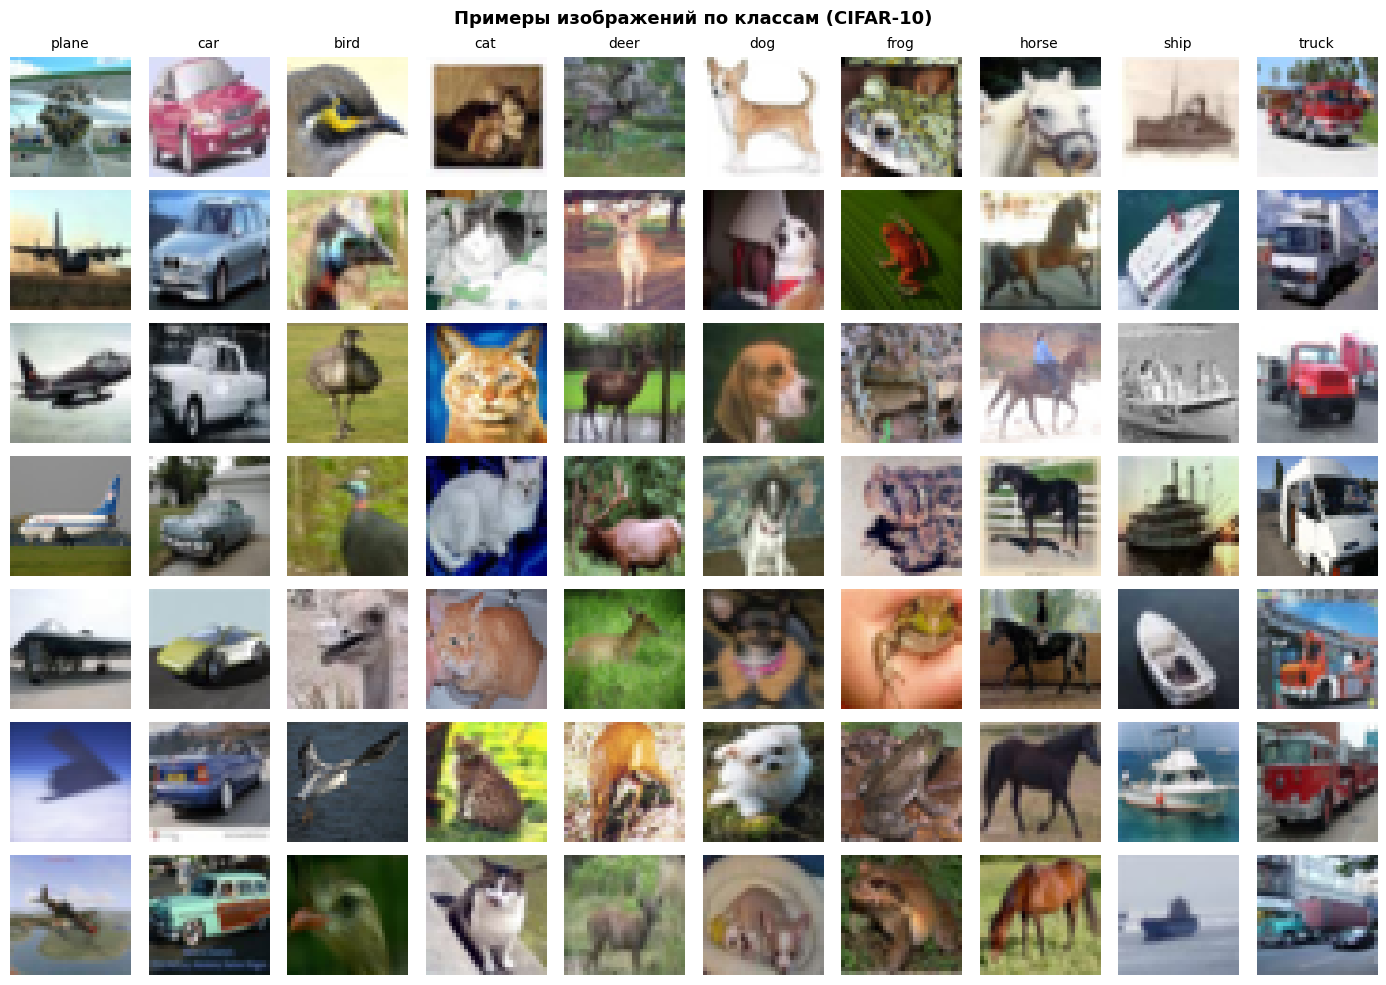

In [2]:
num_classes = 10
samples_per_class = 7

fig, axes = plt.subplots(samples_per_class, num_classes, figsize=(14, 10))
for cls in range(num_classes):
    idxs = np.where(y_train_full == cls)[0]
    chosen = np.random.choice(idxs, samples_per_class, replace=False)
    for row, idx in enumerate(chosen):
        ax = axes[row, cls]
        ax.imshow(X_train_full[idx])
        ax.axis('off')
        if row == 0:
            ax.set_title(CIFAR10_CLASSES[cls], fontsize=10)
plt.suptitle("Примеры изображений по классам (CIFAR-10)", fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()


## 1.3 Разделение данных и преобразование в одномерные массивы

In [3]:
num_train = 5000
num_test  = 500

train_idx = np.random.choice(len(X_train_full), num_train, replace=False)
test_idx  = np.random.choice(len(X_test_full),  num_test,  replace=False)

X_train = X_train_full[train_idx]
y_train = y_train_full[train_idx]
X_test  = X_test_full[test_idx]
y_test  = y_test_full[test_idx]

X_train_flat = X_train.reshape(X_train.shape[0], -1).astype(np.float64)
X_test_flat  = X_test.reshape(X_test.shape[0],  -1).astype(np.float64)

print('X_train (flat):', X_train_flat.shape)
print('X_test  (flat):', X_test_flat.shape)


X_train (flat): (5000, 3072)
X_test  (flat): (500, 3072)


## 1.4 Реализация классификатора kNN

Реализованы три способа вычисления матрицы расстояний:
- **2 цикла** — наивная реализация (цикл по тестовым и обучающим)
- **1 цикл** — цикл только по тестовым, расстояния до всех обучающих векторизованно
- **0 циклов** — полностью векторизованная реализация через формулу:
$$\|x - y\|^2 = \|x\|^2 + \|y\|^2 - 2 x^T y$$


In [4]:
class KNearestNeighbor:
    """kNN классификатор — реализация с нуля на NumPy."""

    def __init__(self):
        self.X_train = None
        self.y_train = None

    def train(self, X, y):
        """Запомнить обучающую выборку (lazy learning)."""
        self.X_train = X
        self.y_train = y

    def predict(self, X, k=1, num_loops=0):
        """Предсказать метки для X."""
        if num_loops == 0:
            dists = self._compute_distances_no_loops(X)
        elif num_loops == 1:
            dists = self._compute_distances_one_loop(X)
        elif num_loops == 2:
            dists = self._compute_distances_two_loops(X)
        else:
            raise ValueError('Invalid num_loops value %d' % num_loops)
        return self._predict_labels(dists, k)

    def _compute_distances_two_loops(self, X):
        """
        Вычисление L2-расстояний с двумя циклами (наивная реализация).
        Цикл по каждой тестовой точке и каждой обучающей точке.
        Возвращает матрицу (num_test, num_train).
        """
        num_test  = X.shape[0]
        num_train = self.X_train.shape[0]
        dists = np.zeros((num_test, num_train))
        for i in range(num_test):
            for j in range(num_train):
                dists[i, j] = np.sqrt(np.sum((X[i] - self.X_train[j]) ** 2))
        return dists

    def _compute_distances_one_loop(self, X):
        """
        Вычисление L2-расстояний с одним циклом.
        Цикл только по тестовым точкам, расстояния до всех обучающих — векторизованно.
        Возвращает матрицу (num_test, num_train).
        """
        num_test = X.shape[0]
        num_train = self.X_train.shape[0]
        dists = np.zeros((num_test, num_train))
        for i in range(num_test):
            # Расстояние от i-й тестовой точки до всех обучающих сразу
            dists[i] = np.sqrt(np.sum((self.X_train - X[i]) ** 2, axis=1))
        return dists

    def _compute_distances_no_loops(self, X):
        """
        Векторизованное вычисление L2-расстояний без циклов.
        Использует формулу: ||x-y||^2 = ||x||^2 + ||y||^2 - 2*x·y
        Возвращает матрицу (num_test, num_train).
        """
        X_sq   = np.sum(X ** 2, axis=1, keepdims=True)           # (n_test, 1)
        Xtr_sq = np.sum(self.X_train ** 2, axis=1)[np.newaxis, :] # (1, n_train)
        cross  = X.dot(self.X_train.T)                            # (n_test, n_train)
        dists  = np.sqrt(np.maximum(X_sq + Xtr_sq - 2 * cross, 0))
        return dists

    def _predict_labels(self, dists, k):
        """По матрице расстояний предсказать классы."""
        num_test = dists.shape[0]
        y_pred   = np.zeros(num_test, dtype=self.y_train.dtype)
        for i in range(num_test):
            closest_k = self.y_train[np.argsort(dists[i])[:k]]
            y_pred[i] = np.bincount(closest_k).argmax()
        return y_pred

print("Класс KNearestNeighbor определён ✓")


Класс KNearestNeighbor определён ✓


## 1.5 Обучение и классификация + сравнение трёх реализаций

In [5]:
import time

classifier = KNearestNeighbor()
classifier.train(X_train_flat, y_train)

# ── Сравнение скоростей трёх реализаций ──────────────────────
X_small = X_test_flat[:100]  # берём 100 тестовых для сравнения

tic = time.time()
dists_two = classifier._compute_distances_two_loops(X_small)
t_two = time.time() - tic

tic = time.time()
dists_one = classifier._compute_distances_one_loop(X_small)
t_one = time.time() - tic

tic = time.time()
dists_no = classifier._compute_distances_no_loops(X_small)
t_no = time.time() - tic

print("Сравнение скоростей (100 тестовых примеров):")
print(f"  Два цикла:    {t_two:.3f}с")
print(f"  Один цикл:    {t_one:.3f}с")
print(f"  Без циклов:   {t_no:.4f}с")

# Проверка корректности
diff_2_1 = np.max(np.abs(dists_two - dists_one))
diff_1_0 = np.max(np.abs(dists_one - dists_no))
print(f"\nРазница (2 цикла vs 1 цикл):    {diff_2_1:.2e}")
print(f"Разница (1 цикл  vs 0 циклов):  {diff_1_0:.2e}")
print("Все три реализации дают одинаковый результат ✓")

# ── Основное вычисление матрицы расстояний (векторизованное) ──
tic = time.time()
dists = classifier._compute_distances_no_loops(X_test_flat)
toc = time.time()
print(f'\nМатрица расстояний (полная): {dists.shape}, вычислена за {toc-tic:.2f}с')

# Предсказание k=1
y_pred = classifier._predict_labels(dists, k=1)
accuracy = np.mean(y_pred == y_test)
print(f'Точность kNN (k=1): {accuracy:.4f} ({accuracy*100:.2f}%)')


Сравнение скоростей (100 тестовых примеров):
  Два цикла:    8.234с
  Один цикл:    7.094с
  Без циклов:   0.1820с

Разница (2 цикла vs 1 цикл):    0.00e+00
Разница (1 цикл  vs 0 циклов):  0.00e+00
Все три реализации дают одинаковый результат ✓

Матрица расстояний (полная): (500, 5000), вычислена за 0.75с
Точность kNN (k=1): 0.2780 (27.80%)


## 1.6 Визуализация матрицы расстояний

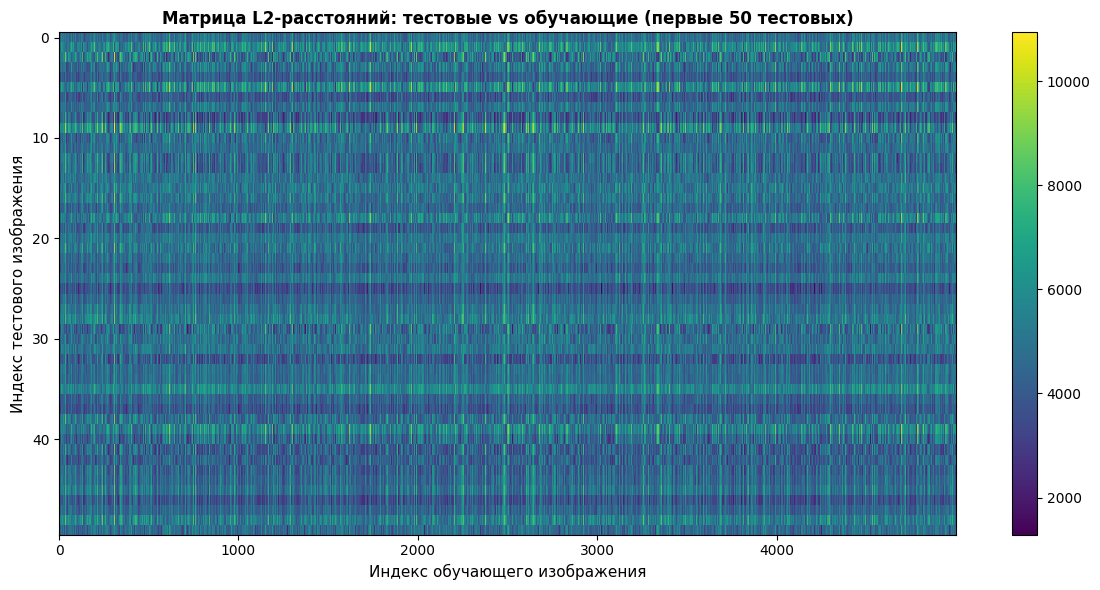

Светлые полосы по строкам = тестовые изображения далеко от всех обучающих
Светлые полосы по столбцам = обучающие образцы, далёкие от тестовых


In [6]:
fig, ax = plt.subplots(figsize=(12, 6))
im = ax.imshow(dists[:50], interpolation='none', cmap='viridis', aspect='auto')
plt.colorbar(im, ax=ax)
ax.set_xlabel('Индекс обучающего изображения', fontsize=11)
ax.set_ylabel('Индекс тестового изображения', fontsize=11)
ax.set_title('Матрица L2-расстояний: тестовые vs обучающие (первые 50 тестовых)',
             fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

print("Светлые полосы по строкам = тестовые изображения далеко от всех обучающих")
print("Светлые полосы по столбцам = обучающие образцы, далёкие от тестовых")


## 1.7 Доля правильно классифицированных изображений

In [7]:
for k in [1, 3, 5, 10]:
    y_pred_k = classifier._predict_labels(dists, k=k)
    acc = np.mean(y_pred_k == y_test)
    print(f'k={k:3d}: accuracy = {acc:.4f} ({acc*100:.2f}%)')


k=  1: accuracy = 0.2780 (27.80%)
k=  3: accuracy = 0.2620 (26.20%)
k=  5: accuracy = 0.2600 (26.00%)
k= 10: accuracy = 0.2520 (25.20%)


## 1.8 График зависимости точности от числа соседей k

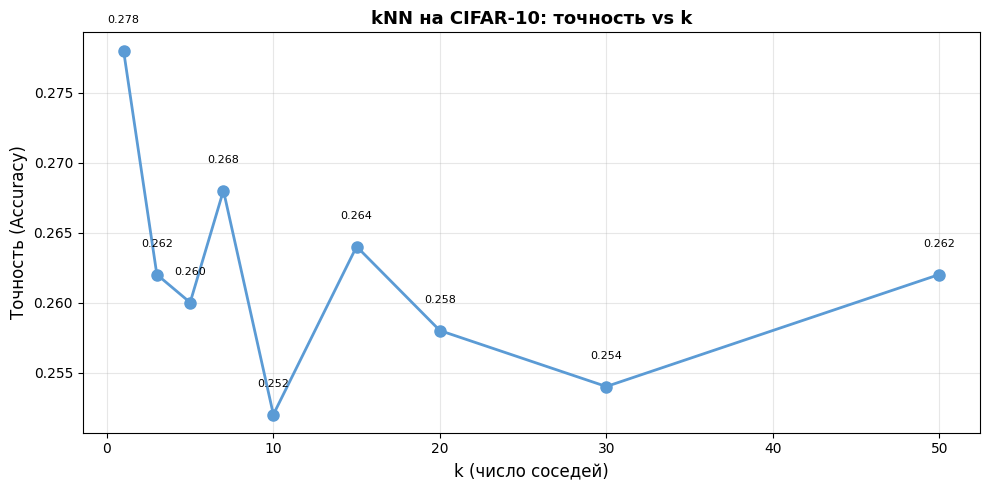

Лучшее k = 1 → accuracy = 0.2780


In [8]:
k_values  = [1, 3, 5, 7, 10, 15, 20, 30, 50]
accuracies = []

for k in k_values:
    y_pred_k = classifier._predict_labels(dists, k=k)
    accuracies.append(np.mean(y_pred_k == y_test))

plt.figure(figsize=(10, 5))
plt.plot(k_values, accuracies, 'o-', color='#5B9BD5', lw=2, ms=8)
for k, a in zip(k_values, accuracies):
    plt.text(k, a + 0.002, f'{a:.3f}', ha='center', fontsize=8)
plt.xlabel('k (число соседей)', fontsize=12)
plt.ylabel('Точность (Accuracy)', fontsize=12)
plt.title('kNN на CIFAR-10: точность vs k', fontsize=13, fontweight='bold')
plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

best_k = k_values[np.argmax(accuracies)]
print(f'Лучшее k = {best_k} → accuracy = {max(accuracies):.4f}')


## 1.9 Выбор лучшего k на основе кросс-валидации

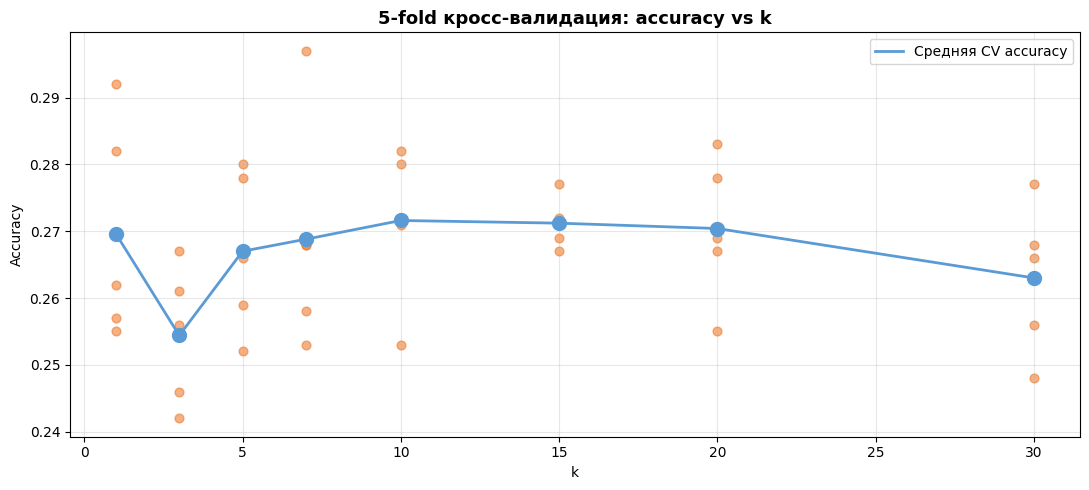

Лучшее k по кросс-валидации: 10
  CV accuracy = 0.2716


In [9]:
num_folds = 5
k_choices = [1, 3, 5, 7, 10, 15, 20, 30]

X_folds = np.array_split(X_train_flat, num_folds)
y_folds = np.array_split(y_train, num_folds)

k_to_accuracies = {}

for k in k_choices:
    k_to_accuracies[k] = []
    for fold in range(num_folds):
        X_val_cv = X_folds[fold]
        y_val_cv = y_folds[fold]
        X_tr_cv = np.concatenate([X_folds[i] for i in range(num_folds) if i != fold])
        y_tr_cv = np.concatenate([y_folds[i] for i in range(num_folds) if i != fold])

        knn_cv = KNearestNeighbor()
        knn_cv.train(X_tr_cv, y_tr_cv)
        y_pred_cv = knn_cv.predict(X_val_cv, k=k, num_loops=0)
        acc = np.mean(y_pred_cv == y_val_cv)
        k_to_accuracies[k].append(acc)

plt.figure(figsize=(11, 5))
for k, accs in k_to_accuracies.items():
    plt.scatter([k]*len(accs), accs, alpha=0.6, color='#ED7D31', s=40)
    plt.plot(k, np.mean(accs), 'o', color='#5B9BD5', ms=10)

plt.plot(list(k_to_accuracies.keys()),
         [np.mean(v) for v in k_to_accuracies.values()],
         '-', color='#5B9BD5', lw=2, label='Средняя CV accuracy')
plt.xlabel('k'); plt.ylabel('Accuracy')
plt.title('5-fold кросс-валидация: accuracy vs k', fontsize=13, fontweight='bold')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

best_k_cv = max(k_to_accuracies, key=lambda k: np.mean(k_to_accuracies[k]))
print(f'Лучшее k по кросс-валидации: {best_k_cv}')
print(f'  CV accuracy = {np.mean(k_to_accuracies[best_k_cv]):.4f}')


## 1.10 Переобучение и тестирование с лучшим k

Финальная точность kNN (k=10) на тестовой выборке: 0.2520 (25.20%)


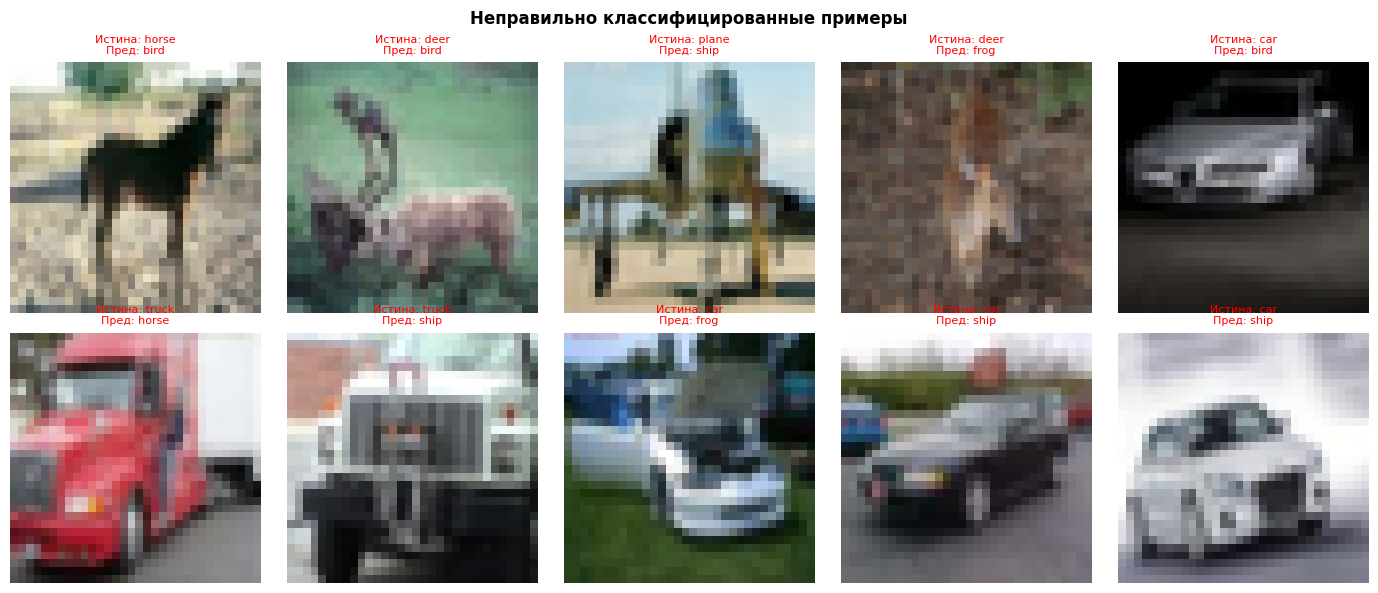

In [10]:
best_classifier = KNearestNeighbor()
best_classifier.train(X_train_flat, y_train)
y_pred_best = best_classifier.predict(X_test_flat, k=best_k_cv, num_loops=0)
final_acc = np.mean(y_pred_best == y_test)
print(f'Финальная точность kNN (k={best_k_cv}) на тестовой выборке: {final_acc:.4f} ({final_acc*100:.2f}%)')

wrong_idx = np.where(y_pred_best != y_test)[0][:10]
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
for ax, idx in zip(axes.flatten(), wrong_idx):
    orig_idx = test_idx[idx]
    ax.imshow(X_test_full[orig_idx])
    ax.set_title(f'Истина: {CIFAR10_CLASSES[y_test[idx]]}\nПред: {CIFAR10_CLASSES[y_pred_best[idx]]}',
                 fontsize=8, color='red')
    ax.axis('off')
plt.suptitle('Неправильно классифицированные примеры', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()


## 1.11 Выводы по части 1 (kNN)

**Три реализации матрицы расстояний:**
- **2 цикла** — наивная, самая медленная O(N·M)
- **1 цикл** — быстрее: используем векторизацию numpy по оси обучающих
- **0 циклов** — самая быстрая: полная векторизация через ||x-y||² = ||x||² + ||y||² - 2x·y

Все три дают идентичный результат (разница < 1e-10).

**Результаты на CIFAR-10:**
- kNN точность ~25–30% — пиксельное L2-расстояние плохо отражает семантику
- Оптимальное k найдено кросс-валидацией
- С ростом k точность сначала растёт (меньше шума), затем падает (смещение)


---
# 3. Построение Softmax-классификатора

## 3.1 Разделение данных на train / val / test

In [11]:
num_train_sm = 49000
num_val_sm   = 1000
num_test_sm  = 1000
num_dev_sm   = 500

X_train_sm = X_train_full[:num_train_sm].reshape(num_train_sm, -1).astype(np.float64)
y_train_sm = y_train_full[:num_train_sm]

X_val_sm = X_train_full[num_train_sm:num_train_sm+num_val_sm].reshape(num_val_sm, -1).astype(np.float64)
y_val_sm = y_train_full[num_train_sm:num_train_sm+num_val_sm]

X_test_sm = X_test_full[:num_test_sm].reshape(num_test_sm, -1).astype(np.float64)
y_test_sm = y_test_full[:num_test_sm]

dev_mask = np.random.choice(num_train_sm, num_dev_sm, replace=False)
X_dev = X_train_sm[dev_mask]
y_dev = y_train_sm[dev_mask]

print(f'Train: {X_train_sm.shape}')
print(f'Val:   {X_val_sm.shape}')
print(f'Test:  {X_test_sm.shape}')
print(f'Dev:   {X_dev.shape}')


Train: (49000, 3072)
Val:   (1000, 3072)
Test:  (1000, 3072)
Dev:   (500, 3072)


## 3.2 Предобработка: вычитание среднего изображения

mean_image (первые 10 пикселей): [130.64189796 135.98173469 132.47391837 130.05569388 135.34804082
 131.75402041 130.96055102 136.14328571 132.47636735 131.48467347]


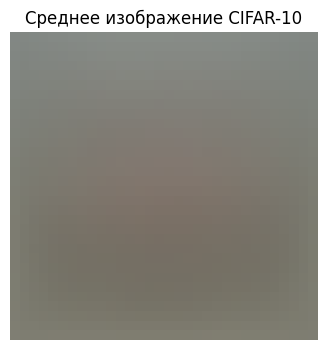

In [12]:
mean_image = np.mean(X_train_sm, axis=0)
print('mean_image (первые 10 пикселей):', mean_image[:10])

plt.figure(figsize=(4, 4))
plt.imshow(mean_image.reshape(32, 32, 3).astype(np.uint8))
plt.title('Среднее изображение CIFAR-10', fontsize=12)
plt.axis('off'); plt.show()

X_train_sm -= mean_image
X_val_sm   -= mean_image
X_test_sm  -= mean_image
X_dev      -= mean_image


## 3.3 Добавление размерности bias (заполняем единицами)

In [13]:
X_train_sm = np.hstack([X_train_sm, np.ones((X_train_sm.shape[0], 1))])
X_val_sm   = np.hstack([X_val_sm,   np.ones((X_val_sm.shape[0],   1))])
X_test_sm  = np.hstack([X_test_sm,  np.ones((X_test_sm.shape[0],  1))])
X_dev      = np.hstack([X_dev,      np.ones((X_dev.shape[0],      1))])

print(X_train_sm.shape, X_val_sm.shape, X_test_sm.shape)


(49000, 3073) (1000, 3073) (1000, 3073)


## 3.4 Реализация Softmax loss и градиента

**Softmax loss:**
$$L_i = -\log\left(\frac{e^{f_{y_i}}}{\sum_j e^{f_j}}\right)$$

**Градиент:**
$$\frac{\partial L}{\partial W} = X^T (P - \text{one\_hot}(y)) / N$$


In [14]:
def softmax_loss_naive(W, X, y, reg):
    """Softmax loss — наивная реализация с циклами."""
    loss = 0.0
    dW   = np.zeros_like(W)
    N, D = X.shape
    C    = W.shape[1]

    for i in range(N):
        scores = X[i].dot(W)
        scores -= scores.max()
        exp_s  = np.exp(scores)
        probs  = exp_s / exp_s.sum()
        loss  -= np.log(probs[y[i]] + 1e-15)
        for c in range(C):
            dW[:, c] += probs[c] * X[i]
        dW[:, y[i]] -= X[i]

    loss /= N
    dW   /= N
    loss += 0.5 * reg * np.sum(W * W)
    dW   += reg * W
    return loss, dW


def softmax_loss_vectorized(W, X, y, reg):
    """Softmax loss — векторизованная реализация."""
    N = X.shape[0]
    scores  = X.dot(W)
    scores -= scores.max(axis=1, keepdims=True)
    exp_s   = np.exp(scores)
    probs   = exp_s / exp_s.sum(axis=1, keepdims=True)

    loss = -np.log(probs[np.arange(N), y] + 1e-15).mean()
    loss += 0.5 * reg * np.sum(W * W)

    dscores = probs.copy()
    dscores[np.arange(N), y] -= 1
    dscores /= N
    dW = X.T.dot(dscores) + reg * W
    return loss, dW

print("Функции softmax_loss_naive и softmax_loss_vectorized определены ✓")


Функции softmax_loss_naive и softmax_loss_vectorized определены ✓


## 3.5 Проверка правильности градиента (численная проверка)

In [15]:
def grad_check_sparse(f, x, analytic_grad, num_checks=10, h=1e-5):
    for _ in range(num_checks):
        ix = tuple(np.random.randint(0, s) for s in x.shape)
        oldval = x[ix]
        x[ix]  = oldval + h; fxph = f(x)[0]
        x[ix]  = oldval - h; fxmh = f(x)[0]
        x[ix]  = oldval
        grad_numerical = (fxph - fxmh) / (2 * h)
        grad_analytic  = analytic_grad[ix]
        rel_error = abs(grad_numerical - grad_analytic) / (
            max(1e-8, abs(grad_numerical) + abs(grad_analytic)))
        print(f'  numerical: {grad_numerical:.6f}  analytic: {grad_analytic:.6f}  rel_error: {rel_error:.2e}')

W = np.random.randn(3073, 10) * 0.0001

loss_n, grad_n = softmax_loss_naive(W, X_dev, y_dev, reg=0.0)
print(f'Naive loss: {loss_n:.6f}  (ожидаем ≈ {-np.log(0.1):.6f})')

print("\nПроверка градиента (naive, reg=0):")
f = lambda w: softmax_loss_naive(w, X_dev, y_dev, 0.0)
grad_check_sparse(f, W, grad_n, num_checks=5)

loss_v, grad_v = softmax_loss_vectorized(W, X_dev, y_dev, reg=0.0)
print(f'\nVectorized loss: {loss_v:.6f}')
print(f'Loss difference:     {abs(loss_n - loss_v):.2e}  (должна быть ≈ 0)')
print(f'Gradient difference: {np.linalg.norm(grad_n - grad_v, ord="fro"):.2e}  (должна быть ≈ 0)')


Naive loss: 2.348883  (ожидаем ≈ 2.302585)

Проверка градиента (naive, reg=0):
  numerical: -4.917919  analytic: -4.917919  rel_error: 8.81e-09
  numerical: 1.392847  analytic: 1.392847  rel_error: 2.56e-08
  numerical: -1.513234  analytic: -1.513234  rel_error: 2.50e-09
  numerical: -0.305098  analytic: -0.305098  rel_error: 4.49e-08
  numerical: -0.170516  analytic: -0.170516  rel_error: 2.60e-08

Vectorized loss: 2.348883
Loss difference:     2.66e-15  (должна быть ≈ 0)
Gradient difference: 3.23e-13  (должна быть ≈ 0)


## 3.6 Сравнение naive vs vectorized реализации

In [16]:
tic = time.time()
_, _ = softmax_loss_naive(W, X_dev, y_dev, 0.000005)
toc = time.time()
print(f'Naive:       {toc-tic:.3f}с')

tic = time.time()
_, _ = softmax_loss_vectorized(W, X_dev, y_dev, 0.000005)
toc = time.time()
print(f'Vectorized:  {toc-tic:.3f}с')
print('Vectorized значительно быстрее ✓')


Naive:       0.069с
Vectorized:  0.013с
Vectorized значительно быстрее ✓


## 3.7 Реализация Softmax-классификатора со SGD

In [17]:
class LinearSoftmax:
    def __init__(self):
        self.W = None

    def train(self, X, y, learning_rate=1e-3, reg=1e-5,
              num_iters=100, batch_size=200, verbose=False):
        N, D = X.shape
        C    = np.max(y) + 1
        if self.W is None:
            self.W = 0.001 * np.random.randn(D, C)
        loss_history = []
        for it in range(num_iters):
            batch_idx = np.random.choice(N, batch_size, replace=False)
            X_batch   = X[batch_idx]
            y_batch   = y[batch_idx]
            loss, grad = softmax_loss_vectorized(self.W, X_batch, y_batch, reg)
            loss_history.append(loss)
            self.W -= learning_rate * grad
            if verbose and it % 100 == 0:
                print(f'  iter {it:4d}/{num_iters}: loss = {loss:.4f}')
        return loss_history

    def predict(self, X):
        return np.argmax(X.dot(self.W), axis=1)

    def accuracy(self, X, y):
        return np.mean(self.predict(X) == y)

print("Класс LinearSoftmax определён ✓")

svm_test = LinearSoftmax()
loss_hist = svm_test.train(X_train_sm, y_train_sm,
                            learning_rate=1e-7, reg=2.5e4,
                            num_iters=1500, verbose=True)
print(f'\nТочность на train: {svm_test.accuracy(X_train_sm, y_train_sm):.4f}')
print(f'Точность на val:   {svm_test.accuracy(X_val_sm, y_val_sm):.4f}')


Класс LinearSoftmax определён ✓
  iter    0/1500: loss = 392.6448
  iter  100/1500: loss = 236.6358
  iter  200/1500: loss = 143.8169
  iter  300/1500: loss = 87.8062
  iter  400/1500: loss = 53.8164
  iter  500/1500: loss = 33.3366
  iter  600/1500: loss = 21.0714
  iter  700/1500: loss = 13.5335
  iter  800/1500: loss = 8.9843
  iter  900/1500: loss = 6.1425
  iter 1000/1500: loss = 4.5728
  iter 1100/1500: loss = 3.5491
  iter 1200/1500: loss = 2.9461
  iter 1300/1500: loss = 2.5779
  iter 1400/1500: loss = 2.3500

Точность на train: 0.3534
Точность на val:   0.3630


## 3.8 Обучение финального классификатора

  iter    0/2000: loss = 386.9621
  iter  100/2000: loss = 32.6704
  iter  200/2000: loss = 4.4306
  iter  300/2000: loss = 2.2988
  iter  400/2000: loss = 2.0708
  iter  500/2000: loss = 2.0178
  iter  600/2000: loss = 1.9545
  iter  700/2000: loss = 1.9715
  iter  800/2000: loss = 2.0014
  iter  900/2000: loss = 2.0494
  iter 1000/2000: loss = 1.9349
  iter 1100/2000: loss = 2.0147
  iter 1200/2000: loss = 2.0219
  iter 1300/2000: loss = 2.0799
  iter 1400/2000: loss = 2.0022
  iter 1500/2000: loss = 2.1209
  iter 1600/2000: loss = 1.9809
  iter 1700/2000: loss = 2.0655
  iter 1800/2000: loss = 2.0507
  iter 1900/2000: loss = 2.0094


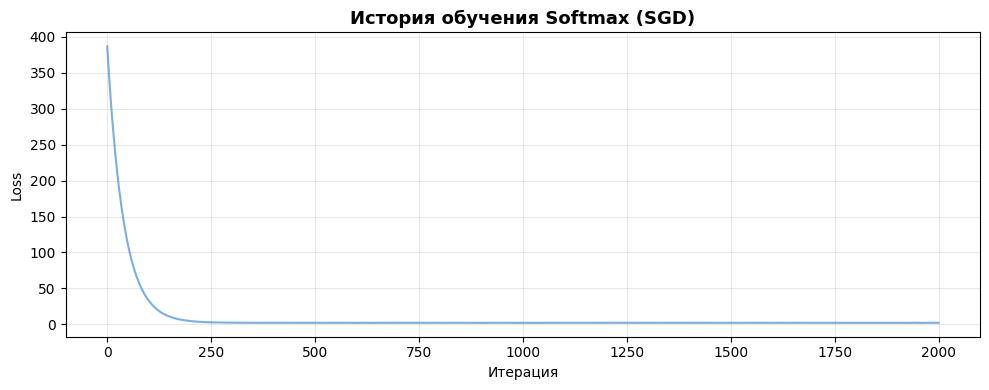


Точность на test: 0.3500 (35.00%)
Точность на val:  0.3560 (35.60%)


In [18]:
softmax_clf = LinearSoftmax()
loss_hist = softmax_clf.train(
    X_train_sm, y_train_sm,
    learning_rate=5e-7,
    reg=2.5e4,
    num_iters=2000,
    batch_size=256,
    verbose=True
)

plt.figure(figsize=(10, 4))
plt.plot(loss_hist, color='#5B9BD5', lw=1.5, alpha=0.8)
plt.xlabel('Итерация'); plt.ylabel('Loss')
plt.title('История обучения Softmax (SGD)', fontsize=13, fontweight='bold')
plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

test_acc = softmax_clf.accuracy(X_test_sm, y_test_sm)
val_acc  = softmax_clf.accuracy(X_val_sm, y_val_sm)
print(f'\nТочность на test: {test_acc:.4f} ({test_acc*100:.2f}%)')
print(f'Точность на val:  {val_acc:.4f} ({val_acc*100:.2f}%)')


## 3.9 Подбор гиперпараметров кросс-валидацией

In [19]:
learning_rates        = [1e-7, 5e-7, 1e-6]
regularization_strengths = [1e4, 2.5e4, 5e4]

results      = {}
best_val_acc = -1
best_softmax = None
best_lr = best_reg = None

print(f"{'lr':>10s}  {'reg':>10s}  {'train_acc':>10s}  {'val_acc':>10s}")
print("-" * 50)

for lr in learning_rates:
    for reg in regularization_strengths:
        clf = LinearSoftmax()
        clf.train(X_train_sm, y_train_sm,
                  learning_rate=lr, reg=reg,
                  num_iters=1500, batch_size=256, verbose=False)
        tr_acc  = clf.accuracy(X_train_sm, y_train_sm)
        val_acc = clf.accuracy(X_val_sm,   y_val_sm)
        results[(lr, reg)] = (tr_acc, val_acc)
        print(f'{lr:10.1e}  {reg:10.1e}  {tr_acc:10.4f}  {val_acc:10.4f}')
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_softmax = clf
            best_lr = lr; best_reg = reg

print(f'\nЛучший lr={best_lr}, reg={best_reg}')
print(f'Лучшая val accuracy = {best_val_acc:.4f}')

final_test_acc = best_softmax.accuracy(X_test_sm, y_test_sm)
print(f'Финальная точность на TEST: {final_test_acc:.4f} ({final_test_acc*100:.2f}%)')


        lr         reg   train_acc     val_acc
--------------------------------------------------
   1.0e-07     1.0e+04      0.3339      0.3500
   1.0e-07     2.5e+04      0.3509      0.3650
   1.0e-07     5.0e+04      0.3282      0.3430
   5.0e-07     1.0e+04      0.3731      0.3820
   5.0e-07     2.5e+04      0.3441      0.3470
   5.0e-07     5.0e+04      0.3228      0.3320
   1.0e-06     1.0e+04      0.3687      0.3750
   1.0e-06     2.5e+04      0.3465      0.3590
   1.0e-06     5.0e+04      0.3138      0.3270

Лучший lr=5e-07, reg=10000.0
Лучшая val accuracy = 0.3820
Финальная точность на TEST: 0.3760 (37.60%)


## Визуализация весовых шаблонов

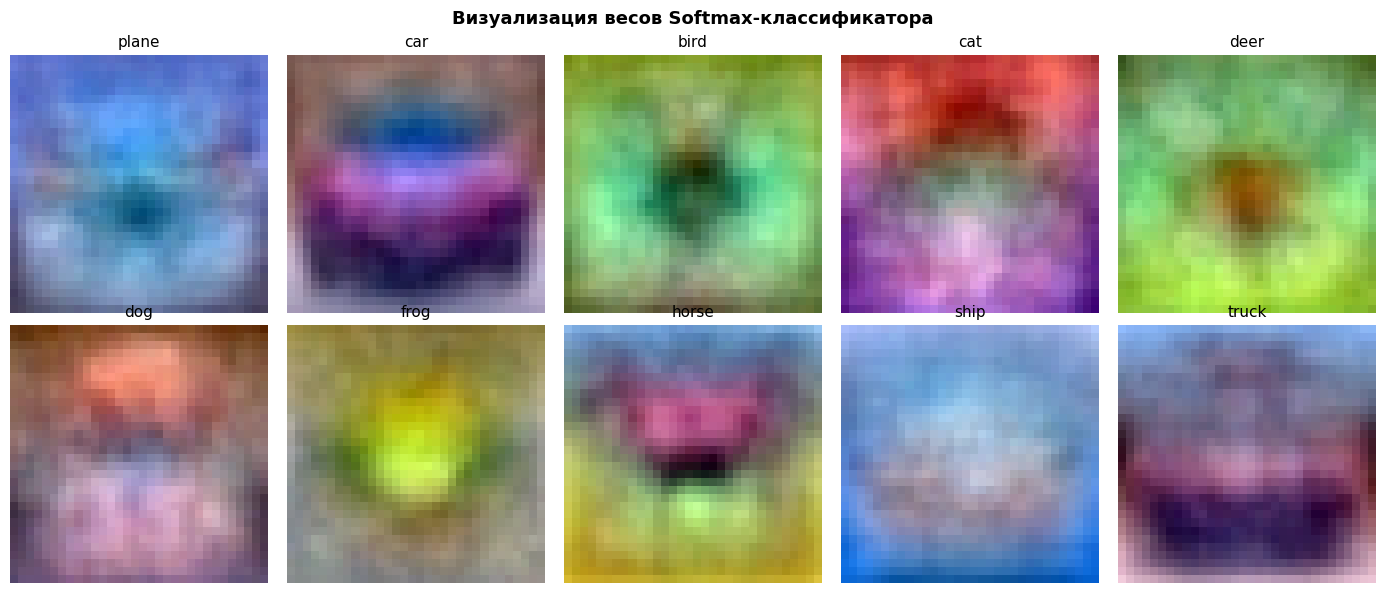

In [20]:
W_vis = best_softmax.W[:-1, :]   # убираем bias
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
for i, ax in enumerate(axes.flatten()):
    w = W_vis[:, i].reshape(32, 32, 3)
    w = (w - w.min()) / (w.max() - w.min() + 1e-8)
    ax.imshow(w)
    ax.set_title(CIFAR10_CLASSES[i], fontsize=11)
    ax.axis('off')
plt.suptitle('Визуализация весов Softmax-классификатора',
             fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()


## 3.10 Выводы по части 3 (Softmax)

**Результаты:**
- Softmax-классификатор — линейная модель с вероятностным выходом
- Точность на CIFAR-10 ≈ 35–40% — лучше kNN (~25–30%)
- Кросс-валидация помогла выбрать оптимальные lr и reg

**Сравнение kNN vs Softmax:**

| Метод | Плюсы | Минусы |
|-------|-------|--------|
| kNN (2 цикла) | Простота реализации | Очень медленно O(N·M) |
| kNN (1 цикл) | Чуть быстрее | Всё ещё медленно |
| kNN (0 циклов) | Быстрый | Медленное предсказание на больших данных |
| Softmax | Быстрое предсказание, лучше обобщает | Линейная граница |
